# 01 - Exploratory Data Analysis
Dataset: processed HILO walking data for two subjects (5 days x 36 control conditions each).

Target: metabolic cost normalised by the subject's normal-walking cost on the same day.

Features: 9 step features, 16 EMG channels, 4 exoskeleton control parameters.

In [1]:
import sys, pathlib, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
from src.config import FIGURES_DIR, FEATURE_GROUPS
from src.data import load_all
from src import eda
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
datasets = load_all()
for name, d in datasets.items():
    print(name, 'X', d.X.shape, '| target mean %.3f, variance %.4f' % (d.y.mean(), d.y.var()))

S1 X (180, 29) | target mean 0.845, variance 0.0657
S2 X (179, 29) | target mean 0.838, variance 0.0358


## Feature groups

In [2]:
{k: len(v) for k, v in FEATURE_GROUPS.items()}

{'all': 29, 'step_emg': 25, 'step': 9, 'emg': 16}

In [3]:
datasets['S1'].to_frame().describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
LFz_peak,180.0,1.097,0.059,0.995,1.051,1.085,1.133,1.290
L_peak_df,180.0,-0.023,0.064,-0.177,-0.069,-0.020,0.017,0.109
L_peak_pf,180.0,0.575,0.200,0.179,0.385,0.627,0.729,0.947
L_step_time,180.0,1.217,0.066,1.090,1.158,1.218,1.271,1.356
RFz_peak,180.0,0.897,0.130,0.443,0.827,0.904,0.983,1.149
R_peak_df,180.0,-0.041,0.074,-0.195,-0.093,-0.043,0.015,0.110
R_peak_pf,180.0,0.562,0.180,0.254,0.388,0.580,0.707,0.975
R_step_time,180.0,1.217,0.066,1.091,1.156,1.221,1.270,1.358
step_width,180.0,-2.204,0.048,-2.327,-2.235,-2.204,-2.169,-2.087
emg1,180.0,0.263,0.027,0.150,0.252,0.267,0.281,0.311


## Metabolic cost drifts from day to day
The subject is still learning to walk with the exoskeleton, so the mean cost drops over the five days. Conditions from the same day are therefore correlated, which is why random k-fold CV is optimistic and leave-one-day-out CV is the more honest test.

In [4]:
eda.day_summary(datasets)

,subject,day,n,mean,std
0,S1,1,36,1.148,0.171
1,S1,2,36,1.061,0.119
2,S1,3,36,0.700,0.099
3,S1,4,36,0.654,0.134
4,S1,5,36,0.660,0.164
5,S2,1,35,1.063,0.206
6,S2,2,36,0.964,0.106
7,S2,3,36,0.740,0.058
8,S2,4,36,0.750,0.088
9,S2,5,36,0.680,0.082


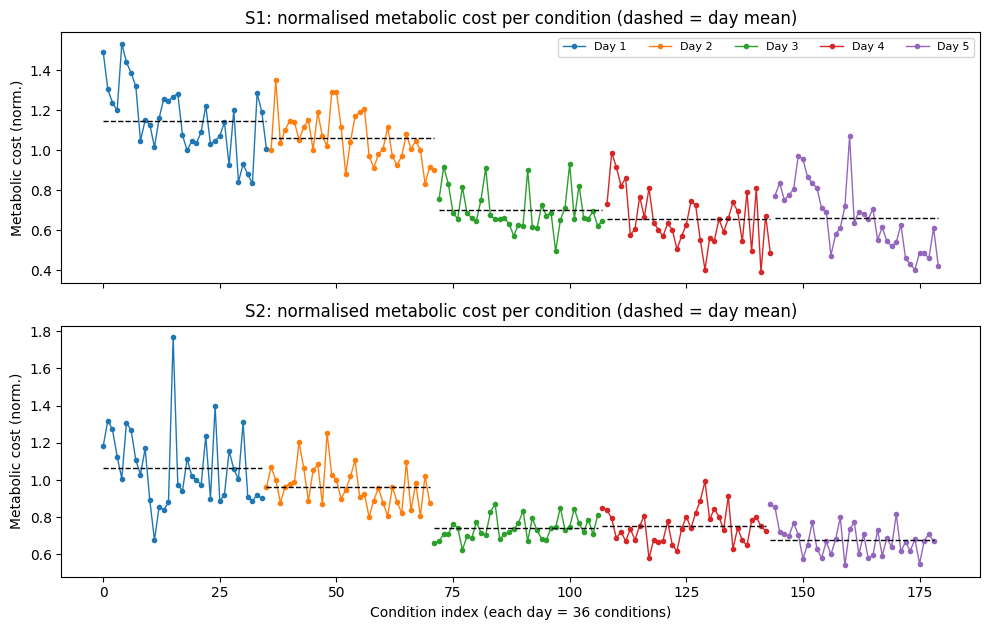

In [5]:
fig = eda.plot_metabolic_by_day(datasets)
fig.savefig(FIGURES_DIR / 'eda_metabolic_by_day.png', dpi=150)
plt.show()

## Which features track metabolic cost?

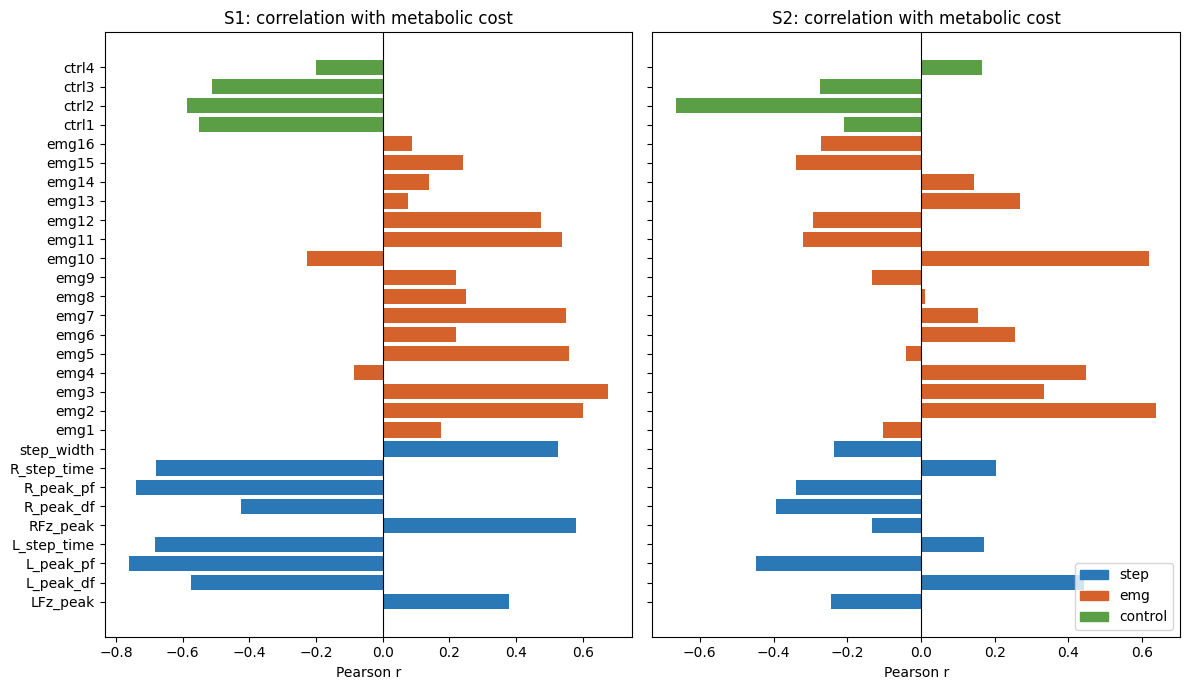

In [6]:
fig = eda.plot_feature_correlations(datasets)
fig.savefig(FIGURES_DIR / 'eda_feature_correlations.png', dpi=150)
plt.show()

In [7]:
for name, d in datasets.items():
    top = eda.feature_target_correlation(d).sort_values(key=abs, ascending=False).head(6)
    print(name, top.round(2).to_dict())

S1 {'L_peak_pf': -0.76, 'R_peak_pf': -0.74, 'L_step_time': -0.68, 'R_step_time': -0.68, 'emg3': 0.68, 'emg2': 0.6}
S2 {'ctrl2': -0.66, 'emg2': 0.64, 'emg10': 0.62, 'L_peak_pf': -0.45, 'emg4': 0.45, 'L_peak_df': 0.44}


## Redundancy between features
Left and right step times are almost perfectly correlated (r close to 1), so the two legs carry largely the same timing information - consistent with the reference paper's observation.

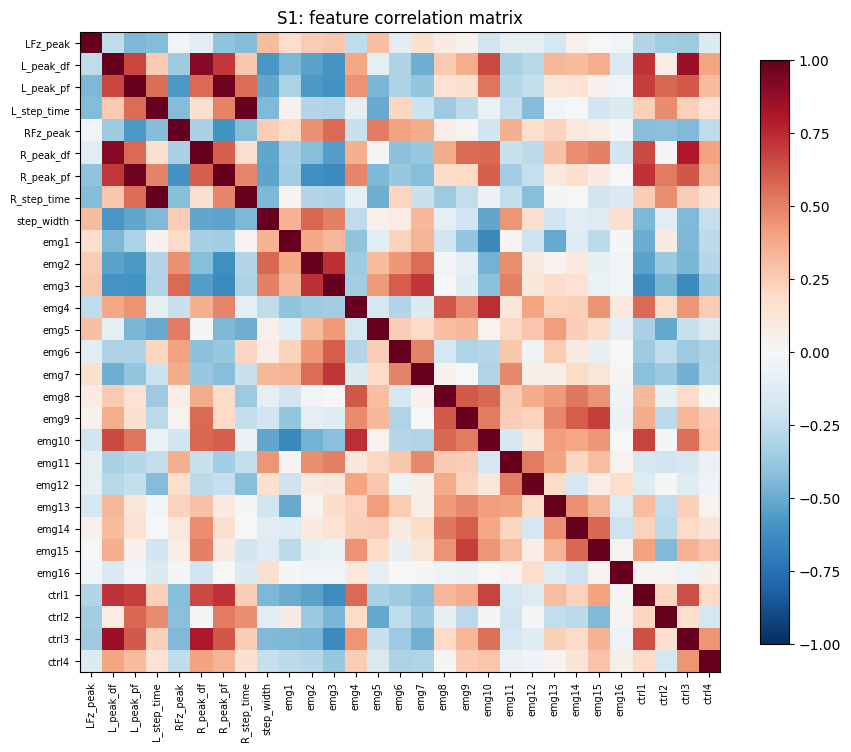

In [8]:
fig = eda.plot_feature_heatmap(datasets['S1'])
fig.savefig(FIGURES_DIR / 'eda_feature_heatmap_S1.png', dpi=150)
plt.show()

## Observations
1. **Strong day effect**: mean cost falls from about 1.1 on day 1 to about 0.7 by day 5 for both subjects.
2. **Step features** (peak plantarflexion, step time) and a few **EMG channels** (emg2, emg3, emg10) correlate most with metabolic cost; the strongest predictors differ between subjects.
3. **Left/right redundancy**: step times of both legs are almost identical.
4. One S2 row has a negative cost (below quiet standing) and is dropped as a sensor error, leaving 179 rows.